In [67]:
import pandas as pd
import numpy as np
import itertools
import time
import random
import warnings
warnings.filterwarnings('ignore')
import math
import sys
import datetime as dt
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as mse
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
from scipy.stats import normaltest
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import Dropout

In [68]:
df=pd.read_csv('/workspaces/Stock-Market-Project/Notebook1/stock_data.csv')
df

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283
...,...,...,...,...,...,...
360,2020-12-26,92.684784,63.408103,98.288992,117.788079,102.995720
361,2020-12-27,92.688279,62.816639,98.061845,116.605106,102.718260
362,2020-12-28,93.551993,63.597651,96.454800,115.441164,103.566068
363,2020-12-29,93.870037,64.114492,95.747485,113.856107,103.257107


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    str    
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), str(1)
memory usage: 20.8 KB


In [70]:
df.isna().sum()

Unnamed: 0    0
Stock_1       0
Stock_2       0
Stock_3       0
Stock_4       0
Stock_5       0
dtype: int64

In [71]:
print(df.columns)

Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='str')


In [72]:
data = df['Stock_1'].values[-180:-60]
test = df['Stock_1'].values[-60:]

In [73]:
X = df[-180:-60]
X.reset_index(drop=True, inplace=True)

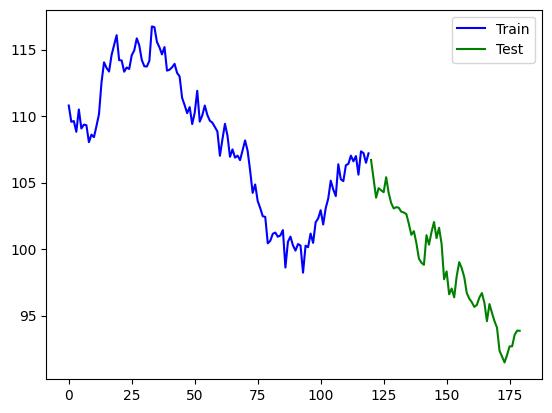

In [74]:
plt.plot(data, c='b', label='Train')
plt.plot(len(data)+np.array(range(len(test))), test, c='g', label='Test')
plt.legend()

plt.show()

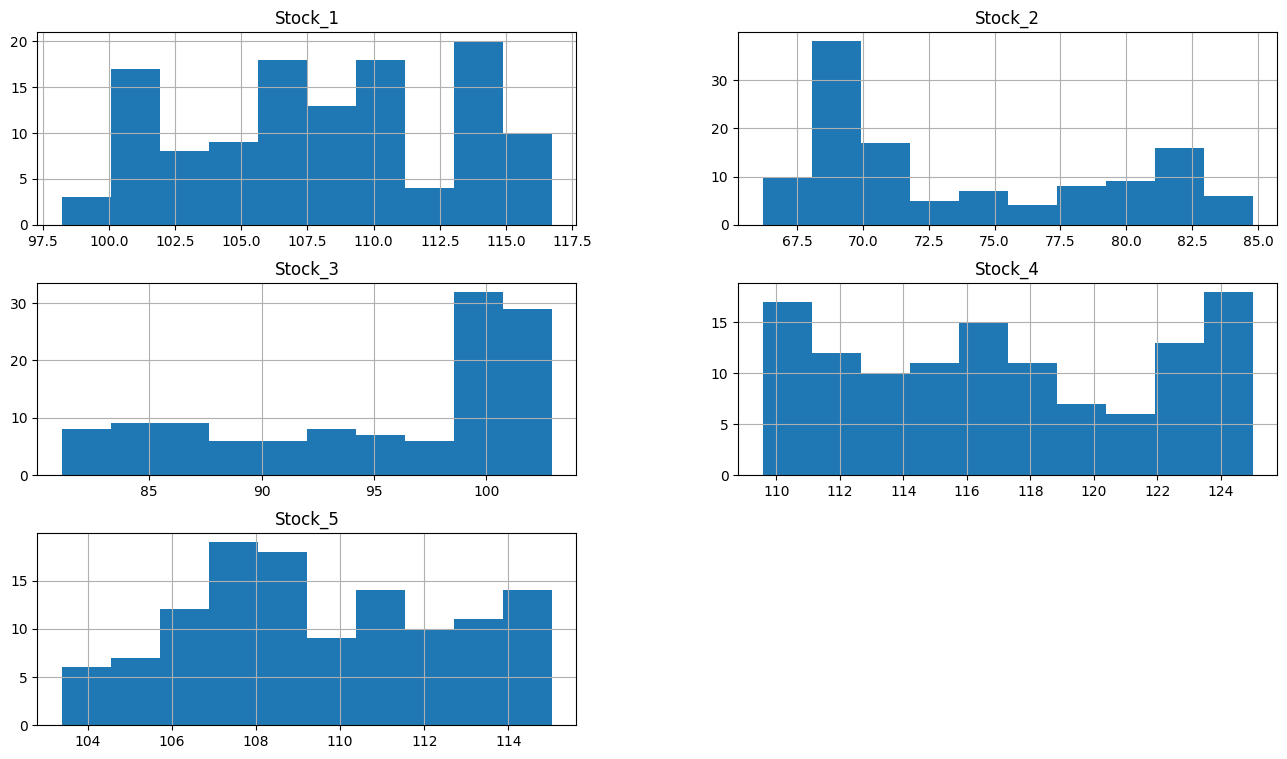

In [75]:
X.hist(figsize=(16,9))

plt.show()

In [76]:

def ts_diagnostics(y, lags=None, title=''):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    # weekly moving averages (5 day week -> 2week window)
    roll_mean = y.rolling(window=10).mean()
    roll_std = y.rolling(window=10).std()

    plt.figure(figsize=(16, 10))
    layout = (3, 2)
    ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
    acf_ax = plt.subplot2grid(layout, (1, 0))
    pacf_ax = plt.subplot2grid(layout, (1, 1))
    qq_ax = plt.subplot2grid(layout, (2, 0))
    hist_ax = plt.subplot2grid(layout, (2, 1))

    # time series plot
    y.plot(ax=ts_ax)
    roll_mean.plot(ax=ts_ax, color='crimson', label='rolling-mean');
    roll_std.plot(ax=ts_ax, color='darkslateblue', label='rolling-std');
    ts_ax.legend(loc='best')
    ts_ax.set_title(title, fontsize=24);

    # acf and pacf
    plot_acf(y, lags=lags, ax=acf_ax, alpha=0.5)
    plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.5)

    # qq plot
    sm.qqplot(y, line='s', ax=qq_ax)
    qq_ax.set_title('QQ Plot')

    # hist plot
    y.plot(ax=hist_ax, kind='hist', bins=25);
    hist_ax.set_title('Histogram');
    plt.tight_layout();
    plt.show()

    # perform Augmented Dickey Fuller test
    print('Dickey-Fuller test:')
    dftest = adfuller(y, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['test statistic', 'p-value', '# of lags', '# of observations'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

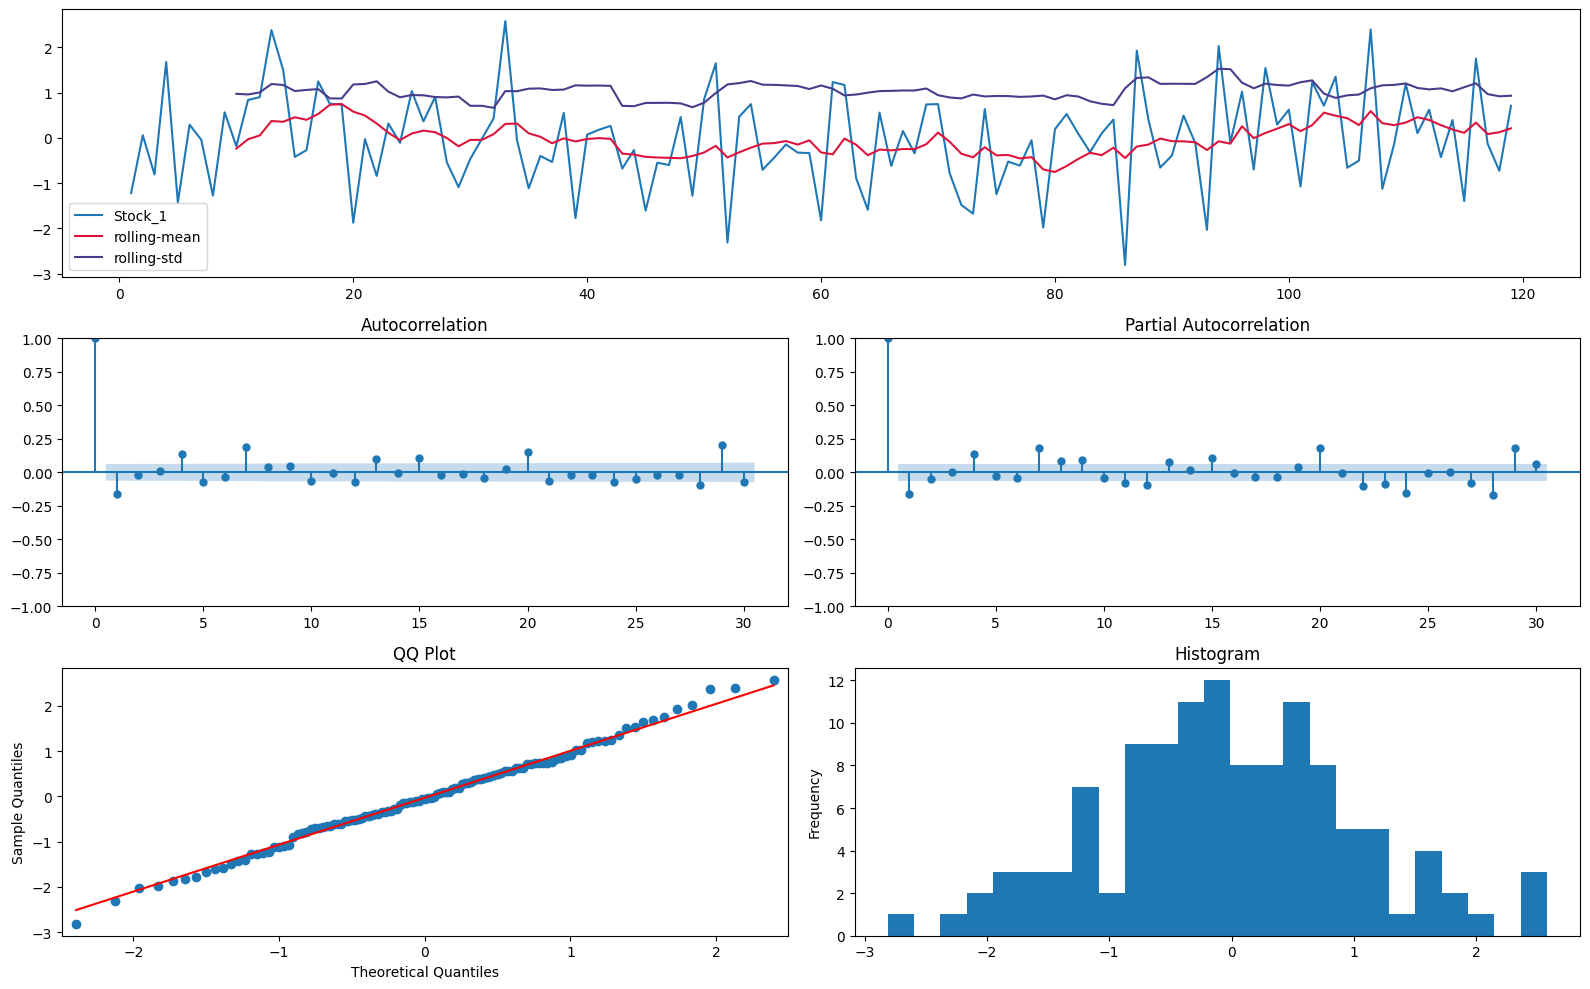

Dickey-Fuller test:
test statistic         -1.270977e+01
p-value                 1.036231e-23
# of lags               0.000000e+00
# of observations       1.180000e+02
Critical Value (1%)    -3.487022e+00
Critical Value (5%)    -2.886363e+00
Critical Value (10%)   -2.580009e+00
dtype: float64


In [77]:
ts_diagnostics(X['Stock_1'].diff().dropna(), lags=30)

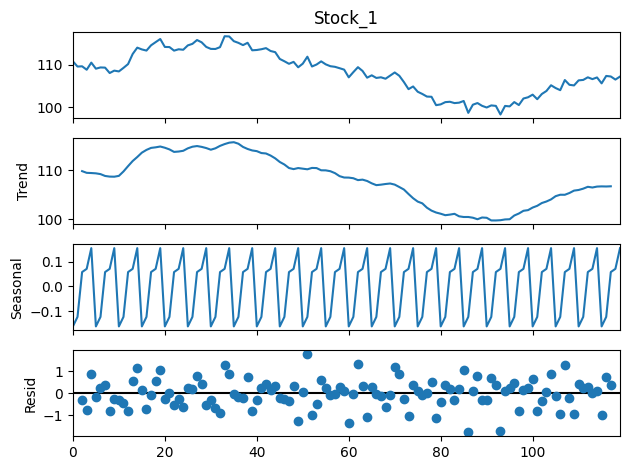

In [78]:
res = seasonal_decompose(X['Stock_1'], model='additive', period=5) 
res.plot()

plt.show()

In [79]:
%%time
### grid search sarima params
model_choice = {}
p = q = range(0, 5)
d = [1]
season = 5
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(i, j, k, season) for i, j, k in pdq]
for order, season in itertools.product(pdq, seasonal_pdq):
    try:
        model = sm.tsa.statespace.SARIMAX(data,
                  order=order,
                  seasonal_order=season).fit(disp=0, method='nm')
    except:
        continue
    model_choice[(order, season)] = mse(data[-14:], model.fittedvalues[-14:])
order, season = min(model_choice, key=model_choice.get)

CPU times: user 3min 2s, sys: 546 ms, total: 3min 3s
Wall time: 1min 42s


In [80]:
order, season = ((4, 1, 1), (4, 1, 4, 5))
order, season

((4, 1, 1), (4, 1, 4, 5))

In [81]:
%%time
clf_sar = sm.tsa.statespace.SARIMAX(data, 
                                    trend='n',
                                    order=order,
                                    seasonal_order=season
                                ).fit(disp=0, method='lbfgs')

CPU times: user 5.1 s, sys: 36.3 ms, total: 5.14 s
Wall time: 3.88 s


In [82]:
clf_sar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                          SARIMAX Results                                           
====================================================================================================
Dep. Variable:                                            y   No. Observations:                  120
Model:             SARIMAX(4, 1, 1)x(4, 1, [1, 2, 3, 4], 5)   Log Likelihood                -163.817
Date:                                      Mon, 04 May 2026   AIC                            355.634
Time:                                              05:31:57   BIC                            393.941
Sample:                                                   0   HQIC                           371.181
                                                      - 120                                         
Covariance Type:                                        opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1615      1.304      0.124      0.901      -2.394       2.717
ar.L2          0.0383      0.190      0.202      0.840      -0.334       0.411
ar.L3          0.0692      0.134      0.516      0.606      -0.193       0.332
ar.L4          0.1288      0.158      0.817      0.414      -0.180       0.438
ma.L1         -0.2970      1.282     -0.232      0.817      -2.810       2.216
ar.S.L5       -0.1329      0.448     -0.296      0.767      -1.011       0.746
ar.S.L10       0.0544      0.430      0.126      0.899      -0.789       0.898
ar.S.L15      -0.5747      0.326     -1.763      0.078      -1.214       0.064
ar.S.L20       0.1921      0.237      0.812      0.417      -0.272       0.656
ma.S.L5       -1.0738     19.681     -0.055      0.956     -39.648      37.501
ma.S.L10       0.0560      4.316      0.013      0.990      -8.404       8.516
ma.S.L15       0.9816      2.151      0.456      0.648      -3.234       5.197
ma.S.L20      -0.9630     19.183     -0.050      0.960     -38.561      36.635
sigma2         0.8013     15.854      0.051      0.960     -30.271      31.874
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.20
Prob(Q):                              0.95   Prob(JB):                         0.91
Heteroskedasticity (H):               0.90   Skew:                             0.08
Prob(H) (two-sided):                  0.75   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

NormaltestResult(statistic=array([3.30994153]), pvalue=array([0.19109764]))


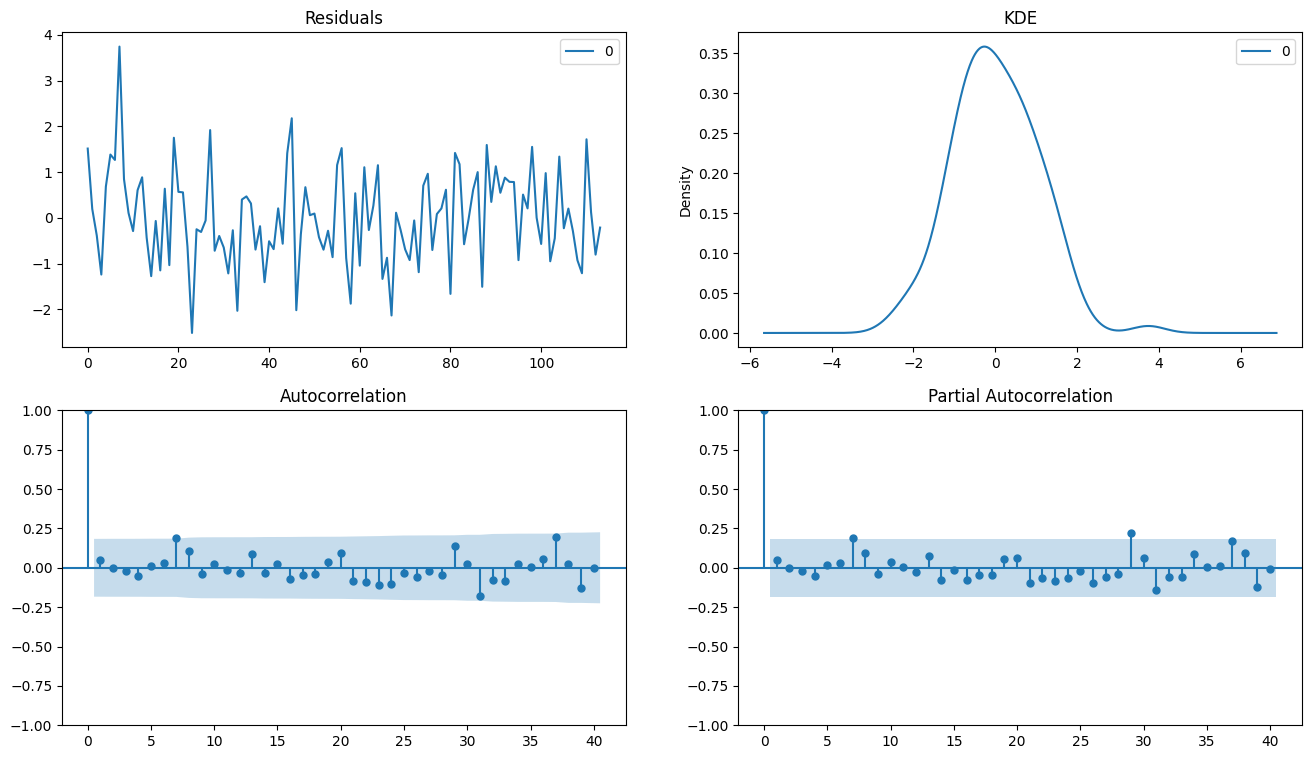

,0
count,114.000000
mean,0.013713
std,1.035579
min,-2.517940
25%,-0.692837
50%,-0.040844
75%,0.678986
max,3.744700


In [83]:
resid = pd.DataFrame(clf_sar.resid[6:])
print(normaltest(resid))

plt.figure(figsize=(16, 9))
layout = (2, 2)
res_ax = plt.subplot2grid(layout, (0, 0))
kde_ax = plt.subplot2grid(layout, (0, 1))
acf_ax = plt.subplot2grid(layout, (1, 0))
pacf_ax = plt.subplot2grid(layout, (1, 1))

resid.plot(ax=res_ax, title='Residuals')
resid.plot(ax=kde_ax, kind='kde', title='KDE')
plot_acf(resid, lags=40, ax=acf_ax)
plot_pacf(resid, lags=40, ax=pacf_ax)

plt.show()

resid.describe()

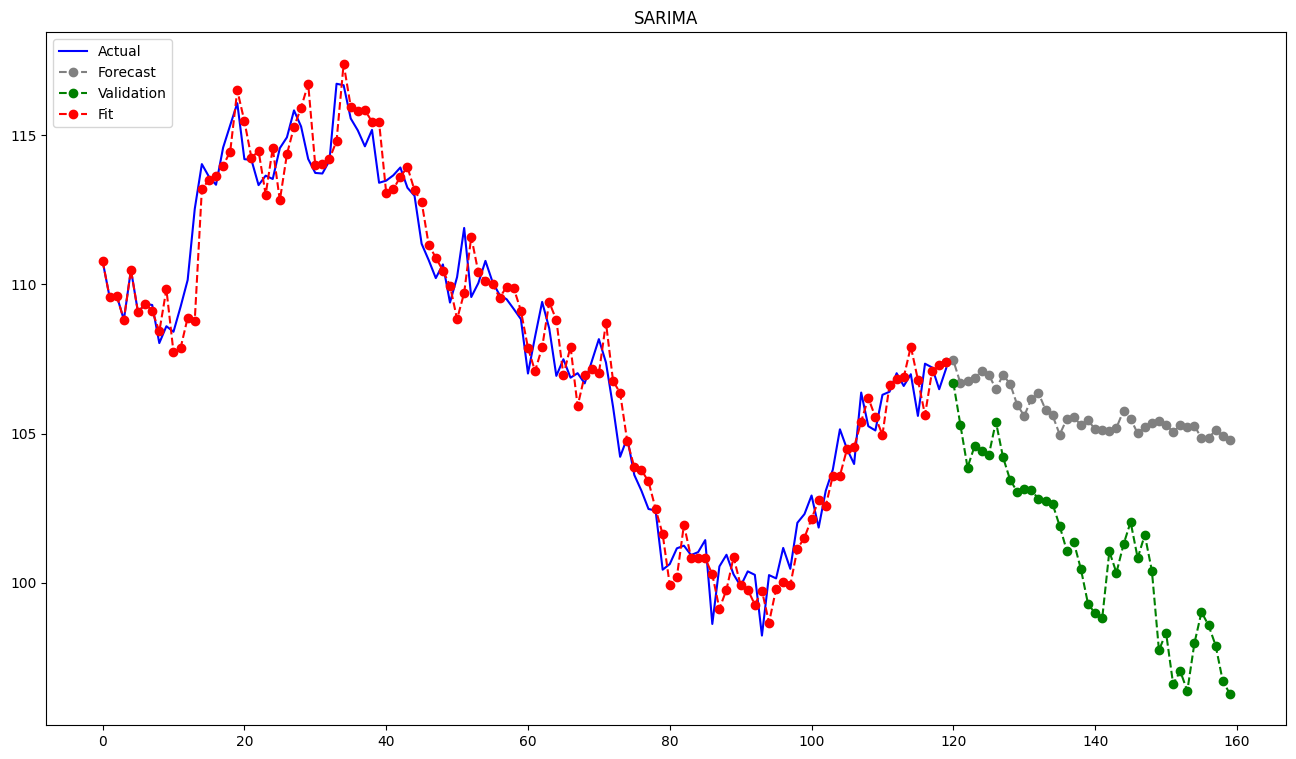

In [84]:
pred_period = 40
x = [i for i in range(len(data) -1, len(data) + pred_period)]
fcast = [clf_sar.fittedvalues[-1]]
for i in clf_sar.forecast(pred_period):
    fcast.append(i)

plt.figure(figsize=(16,9))
plt.plot(X['Stock_1'], 'blue', label = 'Actual')
fit_y = [data[i] if i<7 else clf_sar.fittedvalues[i] 
         for i in range(0, len(data))]
plt.plot(x, fcast, 'o--', c='grey', label ='Forecast')
plt.plot(x[1:], test[:pred_period], 'o--', c='green', label ='Validation')
plt.plot(fit_y, 'o--', color='red', label = 'Fit')
plt.legend(loc=2)
plt.title('SARIMA')

plt.show()

In [85]:
def split_sequence(seq, n_steps):
    X, y = list(), list()
    for i in range(len(seq)):
        end = i + n_steps
        if end > len(seq)-1:
            break
        seq_x, seq_y = seq[i:end], seq[end]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [86]:
seq = X['Stock_1'].values
n_steps = 5
X_train, y_train = split_sequence(seq, n_steps)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

In [87]:
#define model (Vanilla LSTM)
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(n_steps, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
print(model.summary())
model.fit(X_train, y_train, epochs=600, verbose=0)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

None


MSE =  1.5138053893820023


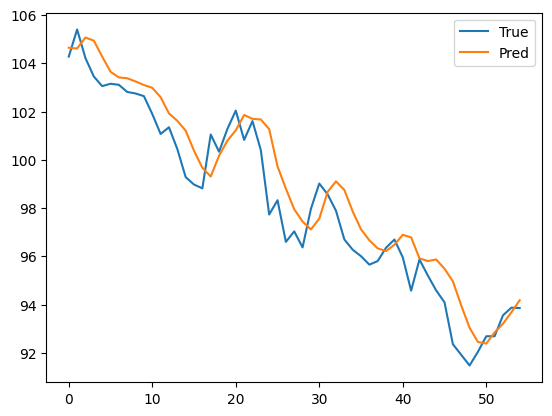

In [88]:
#prediction (Vanilla LSTM)
X_test, y_test = split_sequence(test, n_steps)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
yhat = model.predict(X_test, verbose=0)
print('MSE = ', mse(y_test, yhat))

plt.plot(y_test, label='True')
plt.plot(yhat, label='Pred')
plt.legend()

plt.show()

In [89]:
model = Sequential()
model.add(LSTM(64, activation='relu', return_sequences=True, 
               input_shape=(n_steps, 1)))
model.add(LSTM(64, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
print(model.summary())
model.fit(X_train, y_train, epochs=600, verbose=0)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

None


MSE =  2.208798231268404


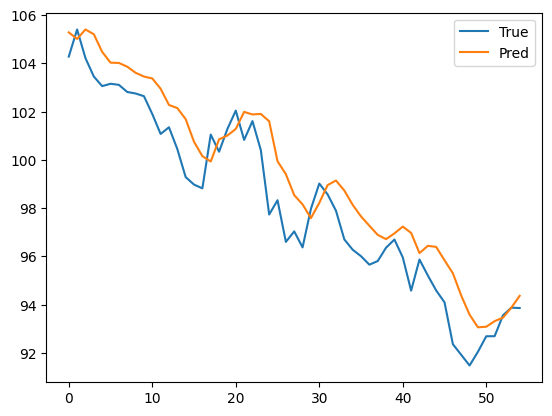

In [90]:
X_test, y_test = split_sequence(test, n_steps)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
yhat = model.predict(X_test, verbose=0)
print('MSE = ', mse(y_test, yhat))

plt.plot(y_test, label='True')
plt.plot(yhat, label='Pred')
plt.legend()

plt.show()

In [91]:
%%time
data = X['Stock_1'].values
alpha = np.linspace(0.0, 0.9, 12)
beta  = np.linspace(0.0, 0.9, 12)
gamma = np.linspace(0.0, 0.9, 12)
seasons = [7]
params = {}
mse_range = -15
for i, j, k in itertools.product(alpha, beta, gamma):
    for s in seasons:
        try:
            fit1 = ExponentialSmoothing(data,seasonal_periods=s,
                                        damped = True, trend='add',
                                        seasonal='add').fit(
                                        smoothing_level=i, smoothing_slope=j,
                                        smoothing_seasonal=k, remove_bias=True)
        except:
            continue
        params[(i, j, k, s)] = mse(data[mse_range:-1],
                                    fit1.fittedvalues[mse_range+1:])

if not params:
    s = 5; alpha = 0.1; beta = 0.1; gamma = 0.4
else:
    alpha, beta, gamma, s = min(params, key=params.get)

CPU times: user 57.4 s, sys: 175 ms, total: 57.6 s
Wall time: 37 s


In [92]:
%%time
clf = ExponentialSmoothing(data, damped = True,
                           seasonal_periods=s, trend='add',
                           seasonal='add').fit(
                           smoothing_level=alpha, smoothing_slope=beta,
                           smoothing_seasonal=gamma, remove_bias=True)

CPU times: user 31.7 ms, sys: 973 μs, total: 32.7 ms
Wall time: 21.8 ms


In [93]:
clf.params

{'smoothing_level': np.float64(0.9),
 'smoothing_trend': np.float64(0.32727272727272727),
 'smoothing_seasonal': np.float64(0.0),
 'damping_trend': np.float64(0.8),
 'initial_level': np.float64(110.59888306833504),
 'initial_trend': np.float64(-0.6064987274607097),
 'initial_seasons': array([ 0.62626993,  0.19460974,  0.01876757, -0.26275394,  0.08884813,
         0.42297097,  0.58034563]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': True}

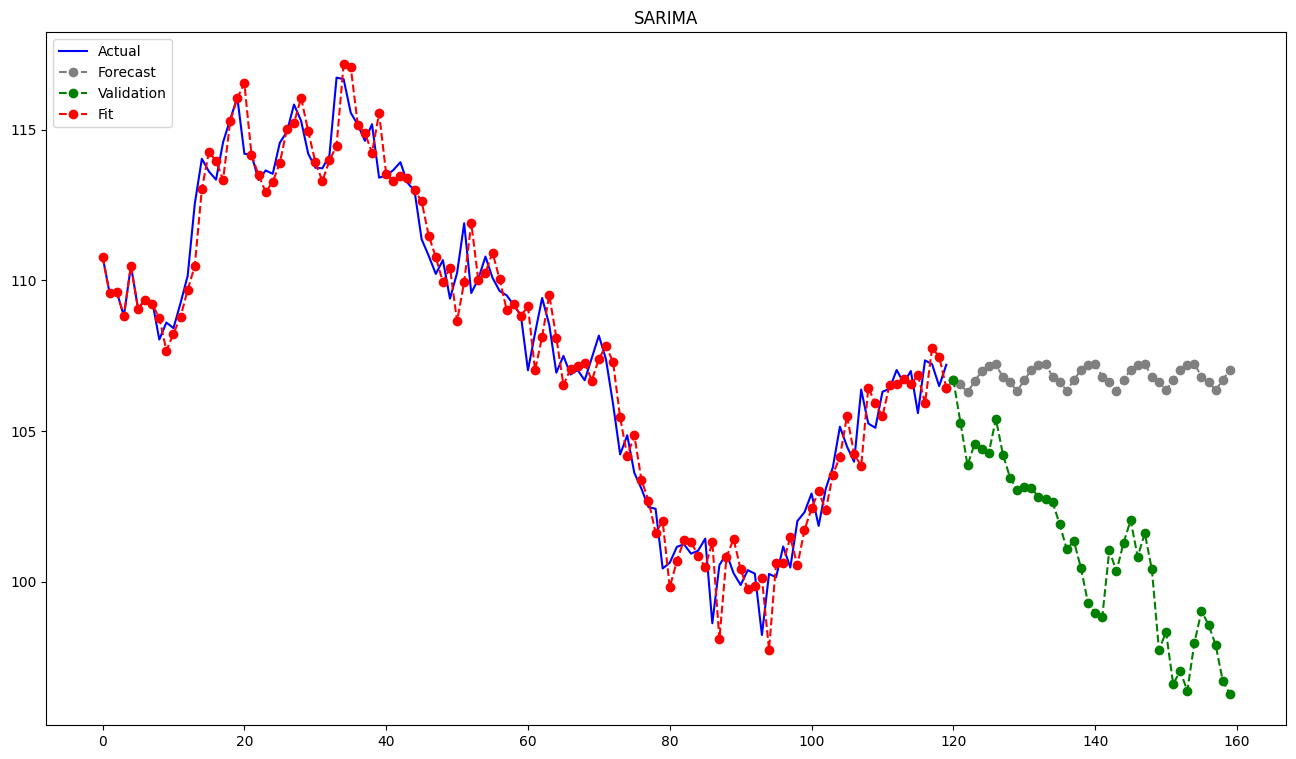

In [94]:
pred_period = 40
x = [i for i in range(len(data)-1, len(data) + pred_period)]
fcast = [clf.fittedvalues[-1]]
for i in clf.forecast(pred_period):
    fcast.append(i)
#s, d = gpf.forecastOutliers(X, metric, clf_sar, 'SARIMAX')
plt.figure(figsize=(16,9))
plt.plot(data, 'blue', label = 'Actual')
fit_y = [data[i] if i<7 else clf.fittedvalues[i] 
         for i in range(0, len(data))]
plt.plot(x, fcast, 'o--', c='grey', label ='Forecast')
plt.plot(x[1:], test[:pred_period], 'o--', c='green', label ='Validation')
plt.plot(fit_y, 'o--', color='red', label = 'Fit')
#plt.xticks(df.index[-120:], xt_cls[-120:], rotation = 90)
# plt.gca().set_yticklabels(['{:.3f}%'.format(x*100) 
#                        for x in plt.gca().get_yticks()])
plt.legend(loc=2)
plt.title('SARIMA')

plt.show()